# Notebook 02 — From Raw C Code to Graph Tensors

Notebook 00 argued *why* code is represented as a graph; Notebook 01 explored the raw data. This notebook shows **how** a raw C/C++ function is turned into the exact tensor object a Graph Neural Network consumes.

The pipeline has four stages, each a reusable component in the `source/` package:

$$ \underbrace{\text{C code}}_{\text{str}} \xrightarrow[\text{tree-sitter}]{\texttt{CodeGraphRepresentator}} \underbrace{\text{AST graph}}_{\texttt{CodeGraph}} \xrightarrow[\text{node features}]{\texttt{CodeNodeRepresentator}} \underbrace{\text{feature vectors}}_{\text{list[float]}} \xrightarrow[\text{assemble}]{\texttt{DataPreprocessingPipeline}} \underbrace{\text{PyG }\texttt{Data}}_{\text{tensors}} $$

Each stage is walked through on a concrete example, visualize the intermediate results, and then show the whole pipeline running end to end.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from source.preprocessing.data_preprocessing.data_representation.data_node_representation.code_node import CodeNode
from source.preprocessing.data_preprocessing.data_representation.data_node_representation.code_node_representator import CodeNodeRepresentator
from source.preprocessing.data_preprocessing.data_representation.data_graph_representation.code_graph_representator import CodeGraphRepresentator

# a small but realistic vulnerable function: unchecked user-controlled index -> out-of-bounds write
example_code = """
int set_value(int *arr, int len, int idx, int value) {
    arr[idx] = value;
    return arr[idx];
}
"""
print(example_code)


int set_value(int *arr, int len, int idx, int value) {
    arr[idx] = value;
    return arr[idx];
}



## Stage 1 — Parsing C into an AST (`CodeGraphRepresentator`)

The first stage uses the [`tree-sitter`](https://tree-sitter.github.io/) parser (via `tree-sitter-c`) to turn source text into an **Abstract Syntax Tree**. The `CodeGraphRepresentator` walks that tree and produces a lightweight `CodeGraph` dataclass with three parallel lists:

- `node_types` — the syntactic type of each node (e.g. `if_statement`, `call_expression`)
- `node_tokens` — the literal text for **leaf** nodes (e.g. the identifier `memcpy`), empty for internal nodes
- `edges` — parent→child index pairs

It also enforces two safety limits from `code_graph_config.py` (`MAX_CODE_BYTES`, `MAX_NODES`) and returns `None` for code that is empty, too large, or unparsable.

In [2]:
representator = CodeGraphRepresentator()
graph = representator.represent(example_code)

print(f"CodeGraph: {graph.num_nodes} nodes, {len(graph.edges)} edges\n")
print(f"{'idx':>3}  {'node_type':<22} token")
print("-" * 45)
for i, (t, tok) in enumerate(zip(graph.node_types, graph.node_tokens)):
    print(f"{i:>3}  {t:<22} {tok!r}")

CodeGraph: 30 nodes, 29 edges

idx  node_type              token
---------------------------------------------
  0  translation_unit       ''
  1  function_definition    ''
  2  primitive_type         'int'
  3  function_declarator    ''
  4  compound_statement     ''
  5  expression_statement   ''
  6  return_statement       ''
  7  subscript_expression   ''
  8  identifier             'arr'
  9  identifier             'idx'
 10  assignment_expression  ''
 11  subscript_expression   ''
 12  identifier             'value'
 13  identifier             'arr'
 14  identifier             'idx'
 15  identifier             'set_value'
 16  parameter_list         ''
 17  parameter_declaration  ''
 18  parameter_declaration  ''
 19  parameter_declaration  ''
 20  parameter_declaration  ''
 21  primitive_type         'int'
 22  identifier             'value'
 23  primitive_type         'int'
 24  identifier             'idx'
 25  primitive_type         'int'
 26  identifier             'len'
 27

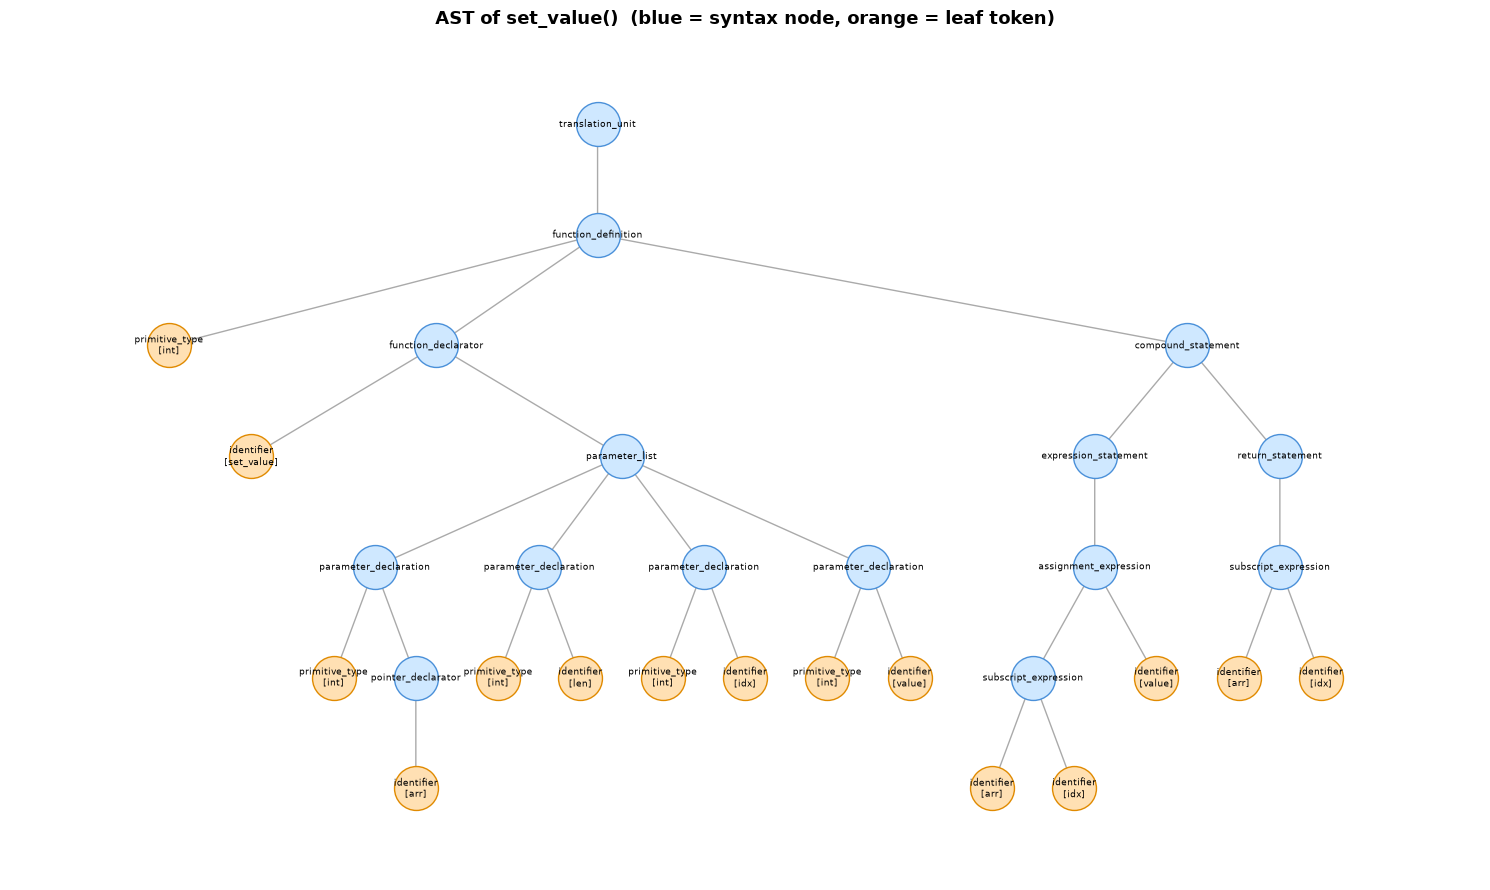

In [3]:
def _tidy_tree_pos(graph):
    """Non-overlapping tree positions: leaves spread evenly, parents centered over children."""
    g = nx.DiGraph()
    g.add_nodes_from(range(graph.num_nodes))
    g.add_edges_from(graph.edges)

    depth = nx.single_source_shortest_path_length(g, 0)
    children = {n: sorted(g.successors(n)) for n in g.nodes}

    x = {}
    counter = [0]

    def assign(node):
        kids = children[node]
        if not kids:
            x[node] = counter[0]
            counter[0] += 1
        else:
            for k in kids:
                assign(k)
            x[node] = sum(x[k] for k in kids) / len(kids)

    assign(0)
    return {n: (x[n], -depth[n]) for n in g.nodes}


def draw_code_graph(graph, title, figsize=(15, 9)):
    g = nx.DiGraph()
    for i, ntype in enumerate(graph.node_types):
        tok = graph.node_tokens[i]
        g.add_node(i, label=f"{ntype}\n[{tok}]" if tok else ntype)
    g.add_edges_from(graph.edges)

    pos = _tidy_tree_pos(graph)

    leaf = [n for n in g.nodes if graph.node_tokens[n]]
    inner = [n for n in g.nodes if not graph.node_tokens[n]]

    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(g, pos, arrows=True, arrowsize=10, edge_color="#aaa")
    nx.draw_networkx_nodes(g, pos, nodelist=inner, node_color="#cfe8ff",
        edgecolors="#4a90d9", node_size=1000)
    nx.draw_networkx_nodes(g, pos, nodelist=leaf, node_color="#ffe0b3",
        edgecolors="#e08a00", node_size=1000)
    nx.draw_networkx_labels(g, pos, nx.get_node_attributes(g, "label"), font_size=6.5)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.margins(0.08)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_code_graph(graph, "AST of set_value()  (blue = syntax node, orange = leaf token)")

## Stage 2 — Turning Nodes into Feature Vectors (`CodeNodeRepresentator`)

A GNN needs a **numeric vector** per node, not a string. `CodeNodeRepresentator` converts each `CodeNode` (its type + token) into a fixed-length feature vector of the form:

$$ \text{node feature} = \big[\underbrace{\text{type\_id}}_{1}\big] \;\Vert\; \underbrace{\text{token features}}_{5} \quad\Rightarrow\quad \text{6 numbers per node} $$

- **`type_id`** — an integer index into a vocabulary of AST node types (built once from the training split, stored in `node_type_vocab.json`). Inside the model this becomes a learned embedding.
- **5 hand-crafted token features** (from `code_node_config.py`), designed with domain knowledge of C vulnerabilities:
  1. is the node a non-empty token? (leaf indicator)
  2. **is it a known dangerous function** (`strcpy`, `memcpy`, `malloc`, `system`, …)?
  3. normalized token length
  4. is it a numeric literal?
  5. does it look like a size/length/buffer variable (`len`, `size`, `buf`, `count`, `idx`)?

Feature #2 and #5 encode the intuition from Notebook 00: memory-safety bugs cluster around dangerous calls and size/index arithmetic.

In [4]:
vocab = CodeNodeRepresentator.load_or_build_vocab()
node_repr = CodeNodeRepresentator(vocab)
print(f"Vocabulary: {len(vocab)} AST node types\n")

# demonstrate the 5 token features on a few illustrative tokens
demo_tokens = ["memcpy", "strcpy", "len", "42", "arr", ""]
feat_names = ["is_token", "is_dangerous", "norm_len", "is_digit", "size_like"]
print(f"{'token':<10} " + "  ".join(f"{f:>12}" for f in feat_names))
print("-" * 78)
for tok in demo_tokens:
    feats = node_repr._token_features(tok)
    print(f"{tok!r:<10} " + "  ".join(f"{v:>12.3f}" for v in feats))

Vocabulary: 112 AST node types

token          is_token  is_dangerous      norm_len      is_digit     size_like
------------------------------------------------------------------------------
'memcpy'          1.000         1.000         0.300         0.000         0.000
'strcpy'          1.000         1.000         0.300         0.000         0.000
'len'             1.000         0.000         0.150         0.000         1.000
'42'              1.000         0.000         0.100         1.000         0.000
'arr'             1.000         0.000         0.150         0.000         0.000
''                0.000         0.000         0.000         0.000         0.000


Feature matrix shape: (30, 6)  (num_nodes x 6 features)


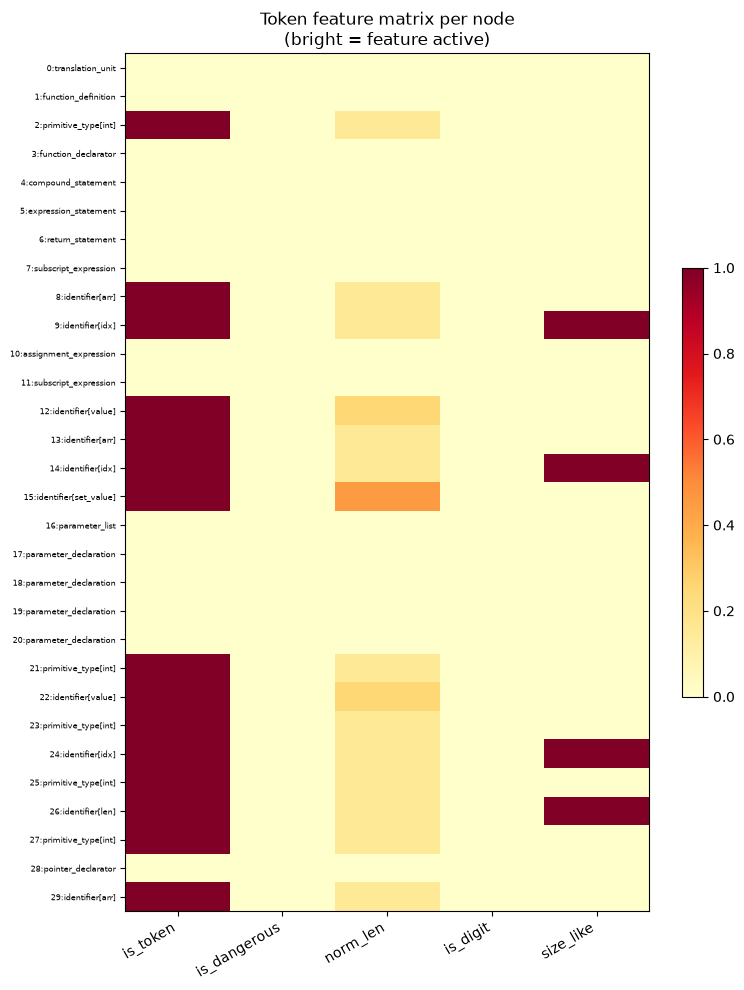

In [5]:
# apply the node representator to every node of our example graph
feature_matrix = np.array([
    node_repr.represent(CodeNode(graph.node_types[i], graph.node_tokens[i]))
    for i in range(graph.num_nodes)
])
print(f"Feature matrix shape: {feature_matrix.shape}  (num_nodes x 6 features)")

# heatmap of the token-feature columns (drop col 0 = raw type_id, which is just an index)
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(feature_matrix[:, 1:], aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(5))
ax.set_xticklabels(feat_names, rotation=30, ha="right")
ax.set_yticks(range(graph.num_nodes))
ax.set_yticklabels([f"{i}:{graph.node_types[i]}" + (f"[{graph.node_tokens[i]}]" if graph.node_tokens[i] else "")
    for i in range(graph.num_nodes)], fontsize=6)
ax.set_title("Token feature matrix per node\n(bright = feature active)")
fig.colorbar(im, ax=ax, shrink=0.5)
plt.tight_layout()
plt.show()

## Stage 3 — Assembling a PyG `Data` Object (`DataPreprocessingPipeline`)

Finally `DataPreprocessingPipeline` glues the stages together and produces a **PyTorch Geometric `Data`** object — the exact input the GNN consumes. Two important details:

- **`x`** = the `[num_nodes, 6]` feature matrix built above.
- **`edge_index`** = a `[2, 2·E]` tensor. The pipeline makes every AST edge **bidirectional** (adds both `parent→child` and `child→parent`) so that messages in the GNN can flow *up and down* the tree, not just downward.
- **`y`** = the function label (0/1) as a length-1 tensor.

The `run()` method streams a whole JSONL split and returns a `list[Data]`; here the internal `_to_data` is called on the single example to inspect the result.

In [6]:
from source.preprocessing.data_preprocessing.data_preprocessing_pipeline import DataPreprocessingPipeline

pipeline = DataPreprocessingPipeline(vocab)
data = pipeline._to_data(graph, label=1)

print("PyG Data object:")
print(f"  {data}")
print(f"\n  x          : {tuple(data.x.shape)}  (float node features)")
print(f"  edge_index : {tuple(data.edge_index.shape)}  (2 x [2*E] — bidirectional)")
print(f"  y          : {data.y.tolist()}  (label)")
print(f"\n  original AST edges : {len(graph.edges)}")
print(f"  edges after making bidirectional : {data.edge_index.shape[1]}  (= 2 x {len(graph.edges)})")

PyG Data object:
  Data(x=[30, 6], edge_index=[2, 58], y=[1])

  x          : (30, 6)  (float node features)
  edge_index : (2, 58)  (2 x [2*E] — bidirectional)
  y          : [1]  (label)

  original AST edges : 29
  edges after making bidirectional : 58  (= 2 x 29)


## Stage 4 — Running the Pipeline on Real Data

To confirm the whole thing works on genuine PrimeVul functions (not just the toy example), the pipeline is run over a **sample** of the validation split and look at the resulting graph sizes. This shows the typical scale of graphs the GNN will process and how many functions get dropped (unparsable / too large / too small).

The raw split is assumed to be present under `data/` (Notebook 01 fetched it). Note that `DataPreprocessingPipeline.run()` also guards this itself: if the requested split is missing, it invokes the `DataFetcher` to download it **before** loading, so the full preprocessing never runs against absent data.

*(A sample is used rather than processing all ~24k to keep the notebook fast; the full preprocessing is what produced `data/processed/*.pt`.)*

In [7]:
import itertools
from source.preprocessing.data_preprocessing.data_loading.data_loader import DataLoader

loader = DataLoader()
VALID_PATH = os.path.join(PROJECT_ROOT, "data", "primevul_valid.jsonl")

SAMPLE = 2000
node_counts, edge_counts, labels = [], [], []
dropped = 0
for rec in itertools.islice(loader.load(VALID_PATH), SAMPLE):
    g = representator.represent(rec["func"])
    if g is None:
        dropped += 1
        continue
    node_counts.append(g.num_nodes)
    edge_counts.append(len(g.edges))
    labels.append(int(rec.get("target", 0)))

node_counts = np.array(node_counts)
labels = np.array(labels)
print(f"Sampled {SAMPLE} functions -> {len(node_counts)} graphs built, {dropped} dropped "
    f"({100*dropped/SAMPLE:.1f}%)")
print(f"Nodes per graph:  median={int(np.median(node_counts))}  "
    f"mean={node_counts.mean():.0f}  max={node_counts.max()}")

Sampled 2000 functions -> 1983 graphs built, 17 dropped (0.8%)
Nodes per graph:  median=87  mean=241  max=2000


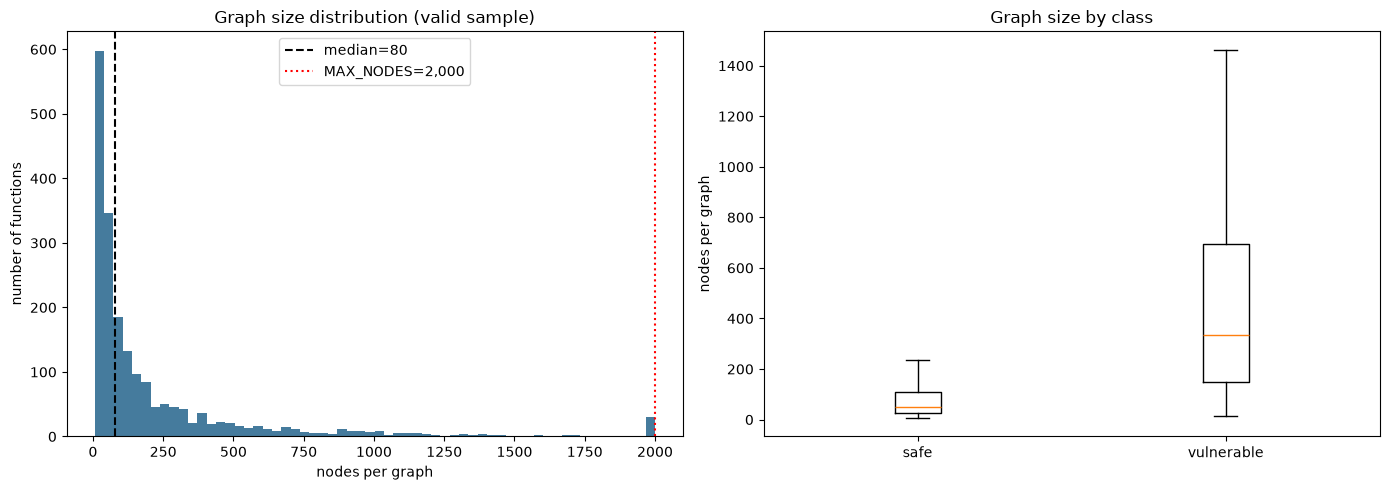

In [8]:
from source.preprocessing.data_preprocessing.data_representation.data_graph_representation.code_graph_config import (
    MAX_NODES,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) distribution of graph sizes
axes[0].hist(node_counts, bins=60, color="#457b9d")
axes[0].axvline(np.median(node_counts), color="black", ls="--",
    label=f"median={int(np.median(node_counts))}")
axes[0].axvline(MAX_NODES, color="red", ls=":", label=f"MAX_NODES={MAX_NODES:,}")
axes[0].set_xlabel("nodes per graph")
axes[0].set_ylabel("number of functions")
axes[0].set_title("Graph size distribution (valid sample)")
axes[0].legend()

# (b) graph size by class — do vulnerable functions tend to be bigger?
axes[1].boxplot([node_counts[labels == 0], node_counts[labels == 1]],
    tick_labels=["safe", "vulnerable"], showfliers=False)
axes[1].set_ylabel("nodes per graph")
axes[1].set_title("Graph size by class")

plt.tight_layout()
plt.show()

## Summary

A raw C function was turned into a GNN-ready tensor through four reusable stages:

| Stage | Component | Input → Output |
|---|---|---|
| 1. Parse | `CodeGraphRepresentator` | C source → `CodeGraph` (AST) |
| 2. Featurize | `CodeNodeRepresentator` | node type + token → 6-D feature vector |
| 3. Assemble | `DataPreprocessingPipeline._to_data` | `CodeGraph` + label → PyG `Data` |
| 4. Batch-process | `DataPreprocessingPipeline.run` | JSONL split → `list[Data]` (saved to `data/processed/*.pt`) |

The design deliberately keeps parsing and featurization **independent** so that either can evolve (e.g. adding control-flow edges, or richer token features) without touching the other. The saved `data/processed/{train,valid,test}.pt` tensors are what **Notebook 03** loads to train the `Vuln47GNN` model.